In [12]:
import numpy as np
import pandas as pd
from dateutil import parser
from datetime import datetime
import os

from one.api import ONE
one = ONE(mode='remote')

In [13]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

## Good QC NM sessions 

In [2]:
# Two-row header: drop the top grouping row, use the second row as column names
# https://docs.google.com/spreadsheets/d/1CvAWvxYUkxXFXvfp1Z9xyFJFOcmSLuicaMFrKXlHFeo/edit?gid=623882528#gid=623882528
nm_qc = pd.read_csv('NM.csv', header=1)

In [18]:
# Filter sessions
filtered = nm_qc.loc[
    (nm_qc['LP status'] == 'TRUE') &
    (nm_qc['session_type'].isin(['ephys', 'biased'])) &
    (nm_qc['video_qc_score'] >= 0.9)
]

# Save list of eids to process later
eids = filtered['eid'].dropna().unique()
pd.Series(eids, name='eid').to_csv('nm_filtered_eids.csv', index=False)
print(f'{len(eids)} sessions passed the filter')

91 sessions passed the filter


## Training session number 1

In [14]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
lda = pd.read_pickle(data_path + 'mouse_LDA_5_bins_cut19-06-2026')
lda = lda.rename(columns={0: 'lda_1'})

lda_mice = lda['mouse_name'].unique()

In [15]:
# Retrieve the first (earliest) training session eid for each LDA mouse directly from ONE
first_training = []
for mouse_name in np.unique(lda_mice):
    # task_protocol='training' substring-matches _iblrig_tasks_trainingChoiceWorld*
    eids, info = one.search(subject=mouse_name, task_protocol='training', details=True)
    if len(eids) == 0:
        print(f'No training sessions found for {mouse_name}')
        continue
    # Results are not date-sorted: pick the earliest (date, then session number for same-day)
    first_idx = min(range(len(eids)), key=lambda i: (info[i]['date'], info[i]['number']))
    first_training.append({'mouse_name': mouse_name,
                           'eid': eids[first_idx],
                           'date': info[first_idx]['date']})

first_training = pd.DataFrame(first_training)
training_sessions = first_training['eid'].tolist()
print(f'{len(training_sessions)} first-training-session eids retrieved of {len(np.unique(lda_mice))} mice')

56 first-training-session eids retrieved of 56 mice


In [16]:
# Save the first-training-session eids for later processing
first_training.to_csv('lda_first_training_eids.csv', index=False)
print(f'Saved {len(first_training)} eids to lda_first_training_eids.csv')

Saved 56 eids to lda_first_training_eids.csv


## Behaviour of the first training session vs LDA 1

For each LDA mouse, pull the first training session's trials from ONE and
correlate basic per-session behavioural metrics against that mouse's mean LDA 1.
Metric conventions follow `Functions/one_functions_generic.py`:
easy trials = `contrast >= 0.5`, `correct = (feedbackType+1)/2`.

In [17]:
from scipy.stats import pearsonr

def session_behavior_metrics(eid):
    """Basic behavioural metrics for one session, computed from ONE trials."""
    t = one.load_object(eid, 'trials', collection='alf')
    cl = np.asarray(t['contrastLeft'], float)
    cr = np.asarray(t['contrastRight'], float)
    fb = np.asarray(t['feedbackType'], float)
    choice = np.asarray(t['choice'], float)
    contrast = np.nan_to_num(cl) + np.nan_to_num(cr)   # absolute contrast (0..1)
    correct = (fb + 1) / 2                             # feedbackType {-1,1} -> {0,1}

    # Reaction time = first-movement latency from stimulus onset
    reaction = np.asarray(t['firstMovement_times'], float) - np.asarray(t['stimOn_times'], float)

    # Infer which numeric choice code means "chose right" from correct right-stimulus trials
    stim_right = ~np.isnan(cr)
    codes = choice[stim_right & (correct == 1) & (choice != 0)]
    right_code = 1 if len(codes) == 0 else pd.Series(codes).mode().iloc[0]
    chose_right = (choice == right_code).astype(float)
    chose_right[choice == 0] = np.nan                  # ignore no-go trials

    easy = contrast >= 0.5
    return {
        'accuracy_easy': np.nanmean(correct[easy]) if easy.sum() else np.nan,
        'trial_count': len(fb),
        'log_reaction': np.log(np.nanmedian(reaction[reaction > 0])),
        'choice_bias': np.abs(np.nanmean(chose_right) - 0.5),   # |P(right) - 0.5|
    }

records = []
for row in first_training.itertuples(index=False):
    try:
        m = session_behavior_metrics(row.eid)
        m['mouse_name'] = row.mouse_name
        m['eid'] = row.eid
        records.append(m)
    except Exception as e:
        print(f'Failed {row.mouse_name} ({row.eid}): {e}')

behavior = pd.DataFrame(records)
print(f'{len(behavior)} sessions with metrics')
behavior.head()

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:436: ALFWarning: Multiple revisions: "", "2024-07-15"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
/home

Downloading: /home/ines/Downloads/ONE/alyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_054/2020-07-20/001/alf/_ibl_trials.stimOffTrigger_times.3e5cde8c-834b-45cc-8785-8f09cea3f24f.npy Bytes: 2928


100%|██████████| 0.0027923583984375/0.0027923583984375 [00:00<00:00,  7.36it/s]


Downloading: /home/ines/Downloads/ONE/alyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_054/2020-07-20/001/alf/_ibl_trials.stimOff_times.53559b48-862e-40d3-b8a7-2b271a090ea9.npy Bytes: 2928


100%|██████████| 0.0027923583984375/0.0027923583984375 [00:00<00:00,  4.64it/s]


...

100%|██████████| 0.00211334228515625/0.00211334228515625 [00:00<00:00,  4.83it/s]


Downloading: /home/ines/Downloads/ONE/alyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-01592/2020-09-16/001/alf/_ibl_trials.stimOffTrigger_times.666e6aad-4f3e-44c2-9fed-989a39cff676.npy Bytes: 2216Downloading: /home/ines/Downloads/ONE/alyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-01592/2020-09-16/001/alf/_ibl_trials.table.c9ea5c3b-f4b7-4be0-9ca2-fc9502920c11.pqt Bytes: 26928



100%|██████████| 0.00211334228515625/0.00211334228515625 [00:00<00:00,  2.06it/s]
100%|██████████| 0.0256805419921875/0.0256805419921875 [00:00<00:00,  6.07s/it]
local file size mismatch on dataset: mainenlab/Subjects/ZFM-01935/2020-11-26/001/alf/_ibl_trials.table.pqt
(S3) /home/ines/Downloads/ONE/alyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-01935/2020-11-26/001/alf/_ibl_trials.table.pqt: 100%|██████████| 34.3k/34.3k [00:00<00:00, 110kB/s]
(S3) /home/ines/Downloads/ONE/alyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-01935/2020-11-26/001/alf/_ibl_trials.stimOff_times.npy: 100%|██████████| 3.12k/3.12k [00:00<00:00, 14.0kB/s]
(S3) /home/ines/Downloads/ONE/alyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-01935/2020-11-26/001/alf/_ibl_trials.quiescencePeriod.npy: 100%|██████████| 3.12k/3.12k [00:00<00:00, 14.2kB/s]
(S3) /home/ines/Downloads/ONE/alyx.internationalbrainlab.org/mainenlab/Subjects/ZFM-01935/2020-11-26/001/alf/_ibl_trials.stimOffTrigger_times.npy: 100%|██████

56 sessions with metrics


,accuracy_easy,trial_count,log_reaction,choice_bias,mouse_name,eid
0,0.524823,282,1.527643,0.072993,CSHL045,b117ed10-6871-42b3-9193-ca708dac4353
1,0.522167,203,1.559419,0.131313,CSHL049,7331502c-ac8b-4d1c-ae35-b384e95088f4
2,0.389497,457,0.369155,0.281182,CSHL052,dc990d49-4e51-4759-992b-292fbe22a7eb
3,0.435714,420,-0.248921,0.146778,CSHL053,85da07f3-b1d4-439d-858d-5e0329a90b6f
4,0.462766,376,1.466210,0.164894,CSHL058,5d217d3f-0540-40b1-ad01-9b819ca3f504


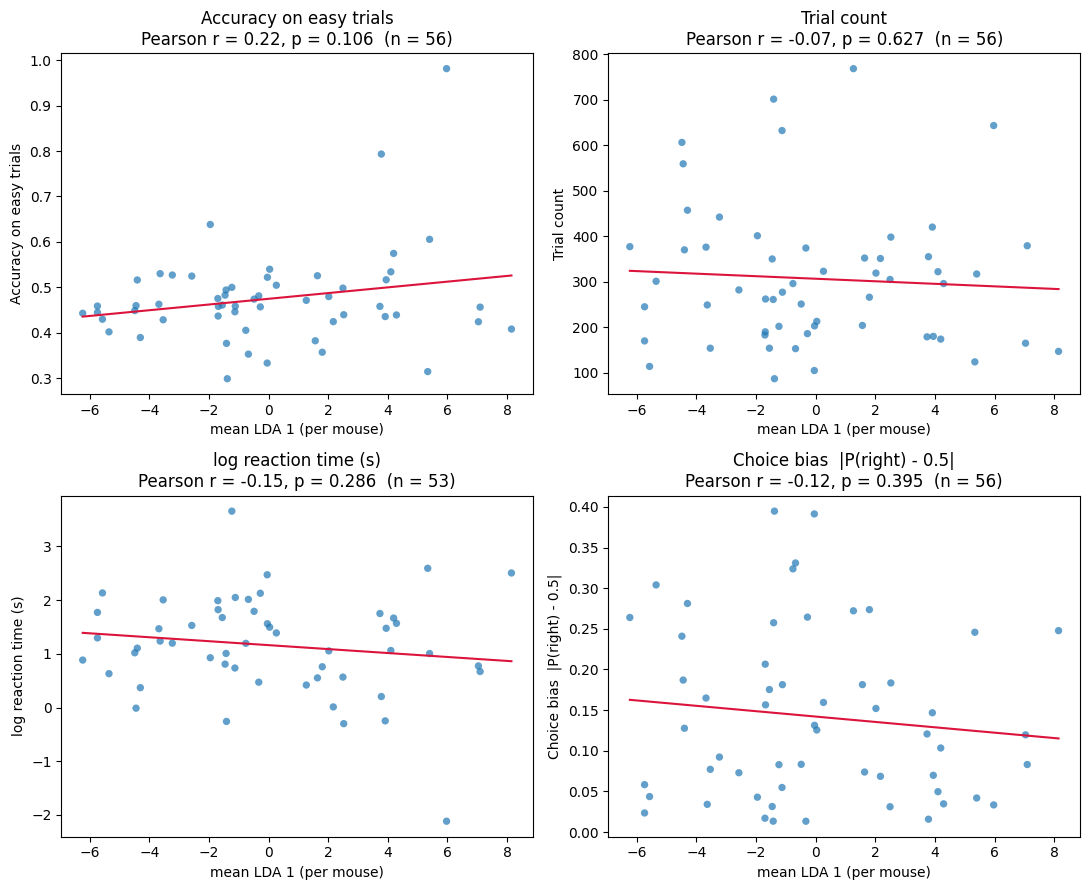

In [18]:
import matplotlib.pyplot as plt

# Mean LDA 1 per mouse
mouse_lda = lda.groupby('mouse_name')['lda_1'].mean().reset_index()
behavior_lda = behavior.merge(mouse_lda, on='mouse_name')

metrics = [('accuracy_easy', 'Accuracy on easy trials'),
           ('trial_count',   'Trial count'),
           ('log_reaction',  'log reaction time (s)'),
           ('choice_bias',   'Choice bias  |P(right) - 0.5|')]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (col, label) in zip(axes.flat, metrics):
    d = behavior_lda[['lda_1', col]].dropna()
    x, y = d['lda_1'].values, d[col].values
    ax.scatter(x, y, s=28, alpha=0.7, edgecolor='none')
    if len(d) > 2:
        r, p = pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, intercept + slope * xs, color='crimson', lw=1.5)
        ax.set_title(f'{label}\nPearson r = {r:.2f}, p = {p:.3g}  (n = {len(d)})')
    else:
        ax.set_title(label)
    ax.set_xlabel('mean LDA 1 (per mouse)')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()